In [4]:
# ==============================
# Data loading / preprocessing / feature engineering
# ==============================

import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler

# ------------------------------
# Reproducibility
# ------------------------------

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# ------------------------------
# Load data
# ------------------------------

df_r = pd.read_csv("Kefra_Processed_Data/Real.csv")
df_fh = pd.read_csv("Kefra_Processed_Data/Fake_High.csv")
df_fl = pd.read_csv("Kefra_Processed_Data/Fake_Low.csv")

# Keep filenames for leakage checks / grouped splits if available, then remove from amplitudes.
real_files = df_r["file"].copy() if "file" in df_r.columns else None
fake_high_files = df_fh["file"].copy() if "file" in df_fh.columns else None
fake_low_files = df_fl["file"].copy() if "file" in df_fl.columns else None

df_r = df_r.drop(columns=["file"], errors="ignore")
df_fh = df_fh.drop(columns=["file"], errors="ignore")
df_fl = df_fl.drop(columns=["file"], errors="ignore")

# ------------------------------
# Convert to numpy arrays
# Each row should be one 512-sample amplitude window
# ------------------------------

X_real = df_r.values.astype(np.float32)
X_fake_high = df_fh.values.astype(np.float32)
X_fake_low = df_fl.values.astype(np.float32)

print("Real shape:", X_real.shape)
print("Fake High shape:", X_fake_high.shape)
print("Fake Low shape:", X_fake_low.shape)

assert X_real.shape[1] == 512, "Expected Real data to have 512 amplitude columns"
assert X_fake_high.shape[1] == 512, "Expected Fake High data to have 512 amplitude columns"
assert X_fake_low.shape[1] == 512, "Expected Fake Low data to have 512 amplitude columns"

# ------------------------------
# Fully shuffle each dataset before any train/test splitting or evaluation.
# This prevents CSV row order from influencing the split or test order.
# ------------------------------

rng = np.random.default_rng(RANDOM_STATE)

real_perm = rng.permutation(len(X_real))
fake_high_perm = rng.permutation(len(X_fake_high))
fake_low_perm = rng.permutation(len(X_fake_low))

X_real = X_real[real_perm]
X_fake_high = X_fake_high[fake_high_perm]
X_fake_low = X_fake_low[fake_low_perm]

if real_files is not None:
    real_files = real_files.iloc[real_perm].reset_index(drop=True)
if fake_high_files is not None:
    fake_high_files = fake_high_files.iloc[fake_high_perm].reset_index(drop=True)
if fake_low_files is not None:
    fake_low_files = fake_low_files.iloc[fake_low_perm].reset_index(drop=True)

# ------------------------------
# 80/20 split for the original single-run experiment
# IMPORTANT:
# Train only on 80% of Real data.
# Test separately on 20% Real, Fake High, Fake Low.
# ------------------------------

X_real_train, X_real_test = train_test_split(
    X_real,
    test_size=0.10,
    random_state=RANDOM_STATE,
    shuffle=True
)

# ------------------------------
# Normalize using ONLY real training data
# This avoids leaking information from fake/test data.
# ------------------------------

scaler = StandardScaler()
X_real_train_scaled = scaler.fit_transform(X_real_train)

X_real_test_scaled = scaler.transform(X_real_test)
X_fake_high_scaled = scaler.transform(X_fake_high)
X_fake_low_scaled = scaler.transform(X_fake_low)

# ------------------------------
# Reshape for Conv1D
# PyTorch Conv1D expects:
# batch_size x channels x sequence_length
# Here: N x 1 x 512
# ------------------------------

X_real_train_tensor = torch.tensor(X_real_train_scaled).unsqueeze(1)
X_real_test_tensor = torch.tensor(X_real_test_scaled).unsqueeze(1)
X_fake_high_tensor = torch.tensor(X_fake_high_scaled).unsqueeze(1)
X_fake_low_tensor = torch.tensor(X_fake_low_scaled).unsqueeze(1)

# ------------------------------
# DataLoaders
# ------------------------------

batch_size = 32

train_loader = DataLoader(
    TensorDataset(X_real_train_tensor),
    batch_size=batch_size,
    shuffle=True
)

real_test_loader = DataLoader(
    TensorDataset(X_real_test_tensor),
    batch_size=batch_size,
    shuffle=False
)

fake_high_loader = DataLoader(
    TensorDataset(X_fake_high_tensor),
    batch_size=batch_size,
    shuffle=False
)

fake_low_loader = DataLoader(
    TensorDataset(X_fake_low_tensor),
    batch_size=batch_size,
    shuffle=False
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Real shape: (110, 512)
Fake High shape: (110, 512)
Fake Low shape: (120, 512)
Using device: cpu


In [5]:
# ==============================
# Training / testing
# ==============================

import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

# ------------------------------
# 1D CNN Autoencoder
# ------------------------------

class Conv1DAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Input: N x 1 x 512
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3),   # 512 -> 256
            nn.ReLU(),

            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2),  # 256 -> 128
            nn.ReLU(),

            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),  # 128 -> 64
            nn.ReLU(),

            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1), # 64 -> 32
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1),  # 32 -> 64
            nn.ReLU(),

            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1),   # 64 -> 128
            nn.ReLU(),

            nn.ConvTranspose1d(32, 16, kernel_size=4, stride=2, padding=1),   # 128 -> 256
            nn.ReLU(),

            nn.ConvTranspose1d(16, 1, kernel_size=4, stride=2, padding=1)     # 256 -> 512
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out


# ------------------------------
# Helper functions
# ------------------------------

def make_loader(X, batch_size=32, shuffle=False):
    """Create a Conv1D DataLoader from a 2D numpy array shaped N x 512."""
    X_tensor = torch.tensor(X.astype(np.float32)).unsqueeze(1)
    return DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=shuffle)


def train_autoencoder(train_loader, num_epochs=75, lr=1e-3, weight_decay=1e-5, verbose=True):
    """Train a fresh CNN autoencoder on one training split."""
    model = Conv1DAutoencoder().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    train_losses = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for batch in train_loader:
            x = batch[0].to(device)

            optimizer.zero_grad()
            x_hat = model(x)

            loss = criterion(x_hat, x)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * x.size(0)

        epoch_loss /= len(train_loader.dataset)
        train_losses.append(epoch_loss)

        if verbose and ((epoch + 1) % 10 == 0 or epoch == 0):
            print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {epoch_loss:.6f}")

    return model, train_losses


def reconstruction_errors(model, loader):
    """Compute per-sample reconstruction MSE."""
    model.eval()
    errors = []

    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device)
            x_hat = model(x)
            batch_errors = torch.mean((x_hat - x) ** 2, dim=(1, 2))
            errors.extend(batch_errors.cpu().numpy())

    return np.array(errors)


def evaluate_split(model, train_loader, real_loader, fake_high_loader, fake_low_loader, threshold_percentile=95):
    """Evaluate one split using a threshold chosen only from real training reconstruction errors."""
    train_errors = reconstruction_errors(model, train_loader)
    real_errors = reconstruction_errors(model, real_loader)
    fake_high_errors = reconstruction_errors(model, fake_high_loader)
    fake_low_errors = reconstruction_errors(model, fake_low_loader)

    threshold = np.percentile(train_errors, threshold_percentile)

    y_real = np.zeros(len(real_errors))
    y_fh = np.ones(len(fake_high_errors))
    y_fl = np.ones(len(fake_low_errors))

    y_true_all = np.concatenate([y_real, y_fh, y_fl])
    scores_all = np.concatenate([real_errors, fake_high_errors, fake_low_errors])
    y_pred_all = (scores_all > threshold).astype(int)

    real_pred = (real_errors > threshold).astype(int)
    fake_high_pred = (fake_high_errors > threshold).astype(int)
    fake_low_pred = (fake_low_errors > threshold).astype(int)

    return {
        "threshold": threshold,
        "train_errors": train_errors,
        "real_errors": real_errors,
        "fake_high_errors": fake_high_errors,
        "fake_low_errors": fake_low_errors,
        "y_true_all": y_true_all,
        "scores_all": scores_all,
        "y_pred_all": y_pred_all,
        "real_false_positive_rate": real_pred.mean(),
        "fake_high_detection_rate": fake_high_pred.mean(),
        "fake_low_detection_rate": fake_low_pred.mean(),
        "roc_auc": roc_auc_score(y_true_all, scores_all),
        "pr_auc": average_precision_score(y_true_all, scores_all),
        "confusion_matrix": confusion_matrix(y_true_all, y_pred_all),
        "train_error_mean": train_errors.mean(),
        "real_error_mean": real_errors.mean(),
        "fake_high_error_mean": fake_high_errors.mean(),
        "fake_low_error_mean": fake_low_errors.mean(),
        "train_error_median": np.median(train_errors),
        "real_error_median": np.median(real_errors),
        "fake_high_error_median": np.median(fake_high_errors),
        "fake_low_error_median": np.median(fake_low_errors),
    }


# ------------------------------
# Single 80/20 experiment
# ------------------------------

num_epochs = 75

print("Training single 80/20 CNN autoencoder...")
model, train_losses = train_autoencoder(
    train_loader,
    num_epochs=num_epochs,
    lr=1e-3,
    weight_decay=1e-5,
    verbose=True
)

single_results = evaluate_split(
    model,
    train_loader,
    real_test_loader,
    fake_high_loader,
    fake_low_loader,
    threshold_percentile=95
)

train_errors = single_results["train_errors"]
real_test_errors = single_results["real_errors"]
fake_high_errors = single_results["fake_high_errors"]
fake_low_errors = single_results["fake_low_errors"]
threshold = single_results["threshold"]

print("\nSingle 80/20 mean reconstruction error:")
print("Train Real:", train_errors.mean())
print("Real Test:", real_test_errors.mean())
print("Fake High:", fake_high_errors.mean())
print("Fake Low:", fake_low_errors.mean())


# ------------------------------
# 5-fold cross-validation
# ------------------------------
# Each fold:
#   1. Trains only on that fold's Real training split.
#   2. Fits scaler only on that fold's Real training split.
#   3. Chooses threshold only from that fold's Real training reconstruction errors.
#   4. Tests on that fold's held-out Real data, plus all Fake High and Fake Low data.
# ------------------------------

run_cross_validation = True
cv_results = []

if run_cross_validation:
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_real), start=1):
        print(f"\n========== Fold {fold}/5 ==========")

        X_train_fold = X_real[train_idx]
        X_test_fold = X_real[test_idx]

        fold_scaler = StandardScaler()
        X_train_fold_scaled = fold_scaler.fit_transform(X_train_fold)
        X_test_fold_scaled = fold_scaler.transform(X_test_fold)
        X_fake_high_fold_scaled = fold_scaler.transform(X_fake_high)
        X_fake_low_fold_scaled = fold_scaler.transform(X_fake_low)

        fold_train_loader = make_loader(X_train_fold_scaled, batch_size=batch_size, shuffle=True)
        fold_real_test_loader = make_loader(X_test_fold_scaled, batch_size=batch_size, shuffle=False)
        fold_fake_high_loader = make_loader(X_fake_high_fold_scaled, batch_size=batch_size, shuffle=False)
        fold_fake_low_loader = make_loader(X_fake_low_fold_scaled, batch_size=batch_size, shuffle=False)

        fold_model, fold_train_losses = train_autoencoder(
            fold_train_loader,
            num_epochs=num_epochs,
            lr=1e-3,
            weight_decay=1e-5,
            verbose=False
        )

        fold_result = evaluate_split(
            fold_model,
            fold_train_loader,
            fold_real_test_loader,
            fold_fake_high_loader,
            fold_fake_low_loader,
            threshold_percentile=95
        )
        fold_result["fold"] = fold
        fold_result["train_size"] = len(train_idx)
        fold_result["real_test_size"] = len(test_idx)
        fold_result["final_train_loss"] = fold_train_losses[-1]
        cv_results.append(fold_result)

        print(f"Threshold:                  {fold_result['threshold']:.6f}")
        print(f"Real false positive rate:   {fold_result['real_false_positive_rate']:.4f}")
        print(f"Fake High detection rate:   {fold_result['fake_high_detection_rate']:.4f}")
        print(f"Fake Low detection rate:    {fold_result['fake_low_detection_rate']:.4f}")
        print(f"ROC AUC:                    {fold_result['roc_auc']:.4f}")
        print(f"PR AUC:                     {fold_result['pr_auc']:.4f}")


Training single 80/20 CNN autoencoder...
Epoch [1/75] - Train Loss: 1.042428
Epoch [10/75] - Train Loss: 0.119000
Epoch [20/75] - Train Loss: 0.072362
Epoch [30/75] - Train Loss: 0.065097
Epoch [40/75] - Train Loss: 0.060808
Epoch [50/75] - Train Loss: 0.055256
Epoch [60/75] - Train Loss: 0.079003
Epoch [70/75] - Train Loss: 0.052926

Single 80/20 mean reconstruction error:
Train Real: 0.05112618
Real Test: 0.053622607
Fake High: 0.3212185
Fake Low: 0.2535393

========== Fold 1/5 ==========
Threshold:                  0.073979
Real false positive rate:   0.0455
Fake High detection rate:   1.0000
Fake Low detection rate:    1.0000
ROC AUC:                    0.9994
PR AUC:                     0.9999

========== Fold 2/5 ==========
Threshold:                  0.094427
Real false positive rate:   0.1364
Fake High detection rate:   1.0000
Fake Low detection rate:    0.9917
ROC AUC:                    0.9903
PR AUC:                     0.9990

========== Fold 3/5 ==========
Threshold:      

Anomaly threshold: 0.077796

Overall Evaluation: Real Test vs Fake High + Fake Low
              precision    recall  f1-score   support

        Real       0.91      0.91      0.91        11
     Anomaly       1.00      1.00      1.00       230

    accuracy                           0.99       241
   macro avg       0.95      0.95      0.95       241
weighted avg       0.99      0.99      0.99       241

Confusion Matrix:
[[ 10   1]
 [  1 229]]
ROC AUC: 0.9984
Average Precision / PR AUC: 0.9999

Separate Dataset Results
Real test false positive rate: 0.0909
Fake High detection rate:     1.0000
Fake Low detection rate:      0.9917

Mean Reconstruction Errors
Train Real:     0.051126
Test Real:      0.053623
Fake High:      0.321218
Fake Low:       0.253539

Median Reconstruction Errors
Train Real:     0.046925
Test Real:      0.047807
Fake High:      0.313279
Fake Low:       0.291260


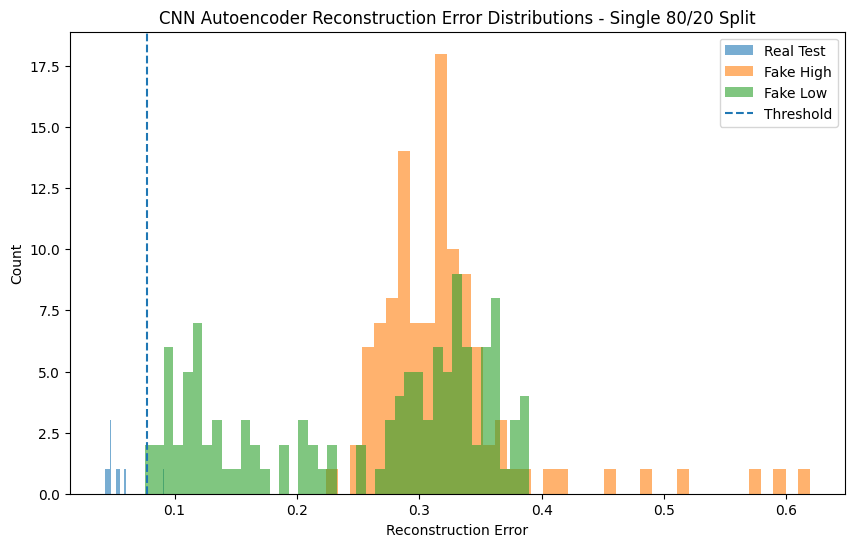

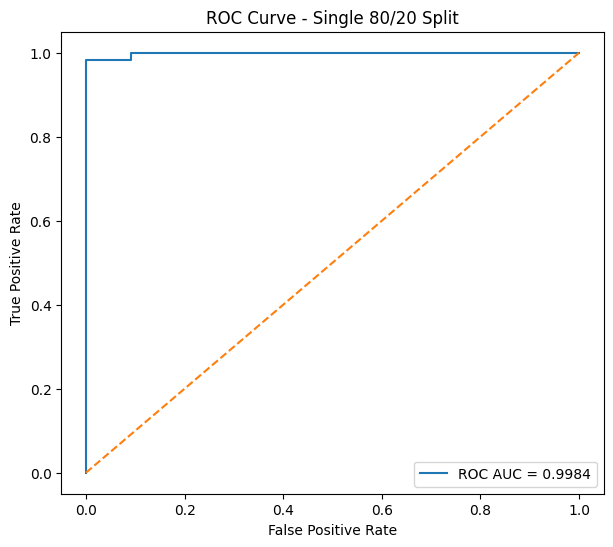

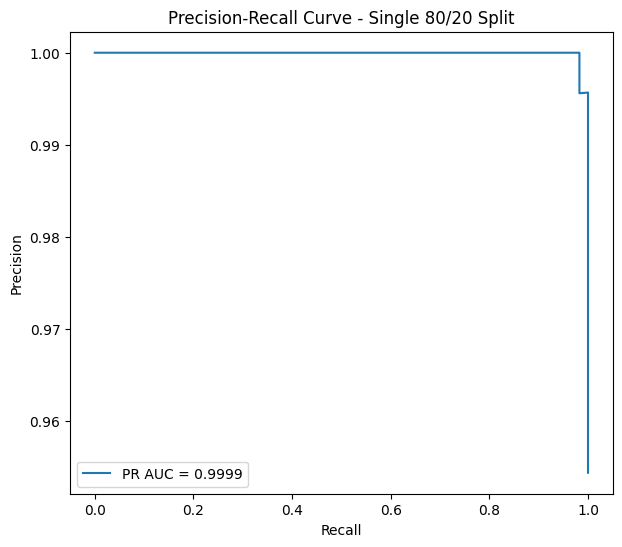

,fold,train_size,real_test_size,threshold,final_train_loss,real_false_positive_rate,fake_high_detection_rate,fake_low_detection_rate,roc_auc,pr_auc,train_error_mean,real_error_mean,fake_high_error_mean,fake_low_error_mean
0,1,88,22,0.073979,0.048599,0.045455,1.0,1.000000,0.999407,0.999943,0.048612,0.049833,0.289589,0.231404
1,2,88,22,0.094427,0.066708,0.136364,1.0,0.991667,0.990316,0.999036,0.066316,0.072953,0.407140,0.311888
2,3,88,22,0.087438,0.056748,0.045455,1.0,0.983333,0.998024,0.999808,0.056547,0.058233,0.334138,0.264362
3,4,88,22,0.080858,0.052935,0.045455,1.0,0.975000,0.994466,0.999440,0.053070,0.054371,0.327624,0.249074
4,5,88,22,0.085227,0.059661,0.090909,1.0,0.966667,0.992490,0.999234,0.055390,0.061539,0.315835,0.236007



5-Fold Cross-Validation Mean ± Std
real_false_positive_rate: 0.0727 ± 0.0407
fake_high_detection_rate: 1.0000 ± 0.0000
fake_low_detection_rate: 0.9833 ± 0.0132
roc_auc: 0.9949 ± 0.0038
pr_auc: 0.9995 ± 0.0004
threshold: 0.0844 ± 0.0076


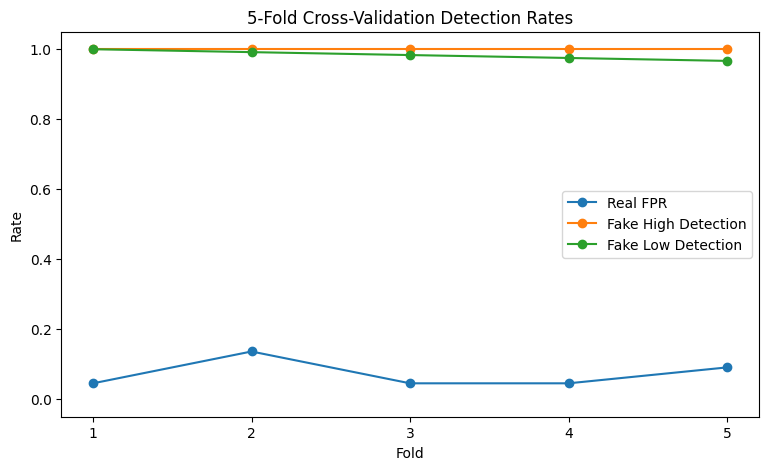

In [6]:
# ==============================
# Evaluating
# ==============================

import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

# ------------------------------
# Single 80/20 evaluation summary
# ------------------------------

print(f"Anomaly threshold: {threshold:.6f}")

# Label convention:
# 0 = Real
# 1 = Anomaly / Fake

y_true_all = single_results["y_true_all"]
scores_all = single_results["scores_all"]
y_pred_all = single_results["y_pred_all"]

print("\nOverall Evaluation: Real Test vs Fake High + Fake Low")
print(classification_report(
    y_true_all,
    y_pred_all,
    target_names=["Real", "Anomaly"]
))

print("Confusion Matrix:")
print(single_results["confusion_matrix"])

print(f"ROC AUC: {single_results['roc_auc']:.4f}")
print(f"Average Precision / PR AUC: {single_results['pr_auc']:.4f}")

print("\nSeparate Dataset Results")
print(f"Real test false positive rate: {single_results['real_false_positive_rate']:.4f}")
print(f"Fake High detection rate:     {single_results['fake_high_detection_rate']:.4f}")
print(f"Fake Low detection rate:      {single_results['fake_low_detection_rate']:.4f}")

print("\nMean Reconstruction Errors")
print(f"Train Real:     {single_results['train_error_mean']:.6f}")
print(f"Test Real:      {single_results['real_error_mean']:.6f}")
print(f"Fake High:      {single_results['fake_high_error_mean']:.6f}")
print(f"Fake Low:       {single_results['fake_low_error_mean']:.6f}")

print("\nMedian Reconstruction Errors")
print(f"Train Real:     {single_results['train_error_median']:.6f}")
print(f"Test Real:      {single_results['real_error_median']:.6f}")
print(f"Fake High:      {single_results['fake_high_error_median']:.6f}")
print(f"Fake Low:       {single_results['fake_low_error_median']:.6f}")

# ------------------------------
# Plot reconstruction error distributions for single 80/20 split
# ------------------------------

plt.figure(figsize=(10, 6))
plt.hist(real_test_errors, bins=40, alpha=0.6, label="Real Test")
plt.hist(fake_high_errors, bins=40, alpha=0.6, label="Fake High")
plt.hist(fake_low_errors, bins=40, alpha=0.6, label="Fake Low")
plt.axvline(threshold, linestyle="--", label="Threshold")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("CNN Autoencoder Reconstruction Error Distributions - Single 80/20 Split")
plt.legend()
plt.show()

# ------------------------------
# ROC curve for single 80/20 split
# ------------------------------

fpr, tpr, _ = roc_curve(y_true_all, scores_all)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {single_results['roc_auc']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Single 80/20 Split")
plt.legend()
plt.show()

# ------------------------------
# Precision-recall curve for single 80/20 split
# ------------------------------

precision, recall, _ = precision_recall_curve(y_true_all, scores_all)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"PR AUC = {single_results['pr_auc']:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Single 80/20 Split")
plt.legend()
plt.show()

# ------------------------------
# 5-fold cross-validation summary
# ------------------------------

if len(cv_results) > 0:
    cv_summary = pd.DataFrame([
        {
            "fold": r["fold"],
            "train_size": r["train_size"],
            "real_test_size": r["real_test_size"],
            "threshold": r["threshold"],
            "final_train_loss": r["final_train_loss"],
            "real_false_positive_rate": r["real_false_positive_rate"],
            "fake_high_detection_rate": r["fake_high_detection_rate"],
            "fake_low_detection_rate": r["fake_low_detection_rate"],
            "roc_auc": r["roc_auc"],
            "pr_auc": r["pr_auc"],
            "train_error_mean": r["train_error_mean"],
            "real_error_mean": r["real_error_mean"],
            "fake_high_error_mean": r["fake_high_error_mean"],
            "fake_low_error_mean": r["fake_low_error_mean"],
        }
        for r in cv_results
    ])

    display(cv_summary)

    metric_cols = [
        "real_false_positive_rate",
        "fake_high_detection_rate",
        "fake_low_detection_rate",
        "roc_auc",
        "pr_auc",
        "threshold",
    ]

    print("\n5-Fold Cross-Validation Mean ± Std")
    for col in metric_cols:
        print(f"{col}: {cv_summary[col].mean():.4f} ± {cv_summary[col].std(ddof=1):.4f}")

    plt.figure(figsize=(9, 5))
    plt.plot(cv_summary["fold"], cv_summary["real_false_positive_rate"], marker="o", label="Real FPR")
    plt.plot(cv_summary["fold"], cv_summary["fake_high_detection_rate"], marker="o", label="Fake High Detection")
    plt.plot(cv_summary["fold"], cv_summary["fake_low_detection_rate"], marker="o", label="Fake Low Detection")
    plt.xlabel("Fold")
    plt.ylabel("Rate")
    plt.title("5-Fold Cross-Validation Detection Rates")
    plt.xticks(cv_summary["fold"])
    plt.ylim(-0.05, 1.05)
    plt.legend()
    plt.show()
